<a href="https://colab.research.google.com/github/min0left-hub/mobis_ai_education_2026/blob/main/DL_05_A_BRKT_VAE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!gdown --folder https://drive.google.com/drive/folders/12_pMH77NyqSnp8NY0EFzZn1dODgrx_p8?usp=drive_link
!unzip dataset/data_3000.zip -d ./data3000

Retrieving folder contents
Processing file 1-sRJSDLohsZlEXFJizzz8ovYZDqJfI-V data_100_test.zip
Processing file 1T6zw4ggFfFlPQChqWia-VLKct1DTSLK6 data_500.zip
Processing file 1kHHoZPyk0_lCJYwqqaxd0hmBAdAxqEQY data_1000.zip
Processing file 12M-FQcVzzumCnhmFrzPkzeBoBZQtBSbj data_2000.zip
Processing file 1pNYu7bAEp8Lw08-VXMmHAgmEnJNhuhAF data_3000.zip
Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1-sRJSDLohsZlEXFJizzz8ovYZDqJfI-V
To: /content/dataset/data_100_test.zip
100% 113k/113k [00:00<00:00, 95.2MB/s]
Downloading...
From: https://drive.google.com/uc?id=1T6zw4ggFfFlPQChqWia-VLKct1DTSLK6
To: /content/dataset/data_500.zip
100% 567k/567k [00:00<00:00, 52.0MB/s]
Downloading...
From: https://drive.google.com/uc?id=1kHHoZPyk0_lCJYwqqaxd0hmBAdAxqEQY
To: /content/dataset/data_1000.zip
100% 1.20M/1.20M [00:00<00:00, 163MB/s]
Downloading...
From: https://drive.google.com/uc?id=12M-FQcVz

In [2]:
import numpy as np
import pandas as pd
import cv2 as cv
import matplotlib.pyplot as plt
import os
import random

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torchsummary import summary

import scipy.io
from sklearn.model_selection import train_test_split
from sklearn.manifold import TSNE
import random
import copy
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from torch.utils.data import TensorDataset, DataLoader, random_split
from torchsummary import summary

In [3]:
def reset_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

reset_seed(42)

Device: cuda


In [4]:

# function to read and display images
def img_read_plot(src,file):
    img = cv.imread(src+file,cv.COLOR_BGR2GRAY)  # convert the image to grayscale
    plt.imshow(img, cmap='gray')
    plt.xticks([])  # x axis
    plt.yticks([])  # y axis
    plt.show()  # display the image
    return img

# function to read images
def img_read(src,file):
    img = cv.imread(src+file,cv.COLOR_BGR2GRAY)  # convert the image to grayscale
    return img

In [5]:
# image size = 56 x 56, 3000 images

# specify the below path to the unzipped data (ensure it ends with '/')
# you can change the file path if needed
src = './data3000/'

files = os.listdir(src)  # get the list of files in the source directory

X,Y = [],[]  # initialize empty lists for storing images and labels

# loop through the files, read each image, and normalize it (0 to 1)
for file in files:
    X.append(img_read(src,file)/255.)  # normalize the image
    Y.append(float(file[:-4]))  # extract label from filename

# convert the data to array
X = np.array(X)
Y = np.array(Y)

# check the shape of the data
print('X.shape:',np.shape(X),'Y.shape:',np.shape(Y))

X.shape: (3000, 56, 56) Y.shape: (3000,)


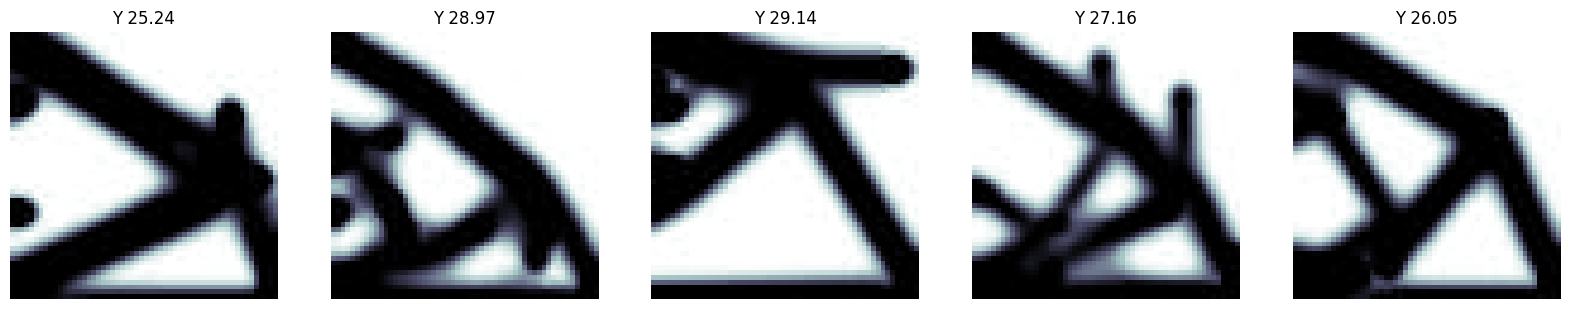

In [6]:
# display images
fig = plt.figure(figsize=(20,10))
nplot = 5

for i in range(1,nplot+1):
    ax = fig.add_subplot(1,nplot,i)
    ax.imshow(X[i, :, :],cmap = plt.cm.bone)
    ax.set_title(f"Y {Y[i]:.2f}")
    ax.axis('off')
plt.show()

In [7]:
# 데이터를 학습용(80%)과 테스트용(20%)으로 나누기
# test set은 나중에 모델이 잘 학습됐는지 검증(validation)용으로 사용 가능
train_images, test_images, train_labels, test_labels = train_test_split(
    X, Y,                 # X: 이미지 데이터, Y: 레이블(정답)
    test_size=0.2,        # 전체 데이터 중 20%를 test set으로
    random_state=1,       # 랜덤 분할 시 같은 결과 나오도록 고정
    shuffle=True          # 데이터를 섞어서 나누기
)

# 학습/테스트 이미지와 라벨의 크기(행렬 shape)와 자료형 출력
print(np.shape(train_images), np.shape(test_images))
print(type(train_images), type(test_images))

print(np.shape(train_labels), np.shape(test_labels))
print(type(train_labels), type(test_labels))


# (image, image) 형태의 2차원 이미지를
# 1차원 벡터로 펼침 (예: 56x56 이미지를 3136차원 벡터로)
# np.prod(train_images.shape[1:]) → 이미지 하나의 전체 픽셀 수
train_images = train_images.reshape(
    (len(train_images), np.prod(train_images.shape[1:]))
).astype('float32')   # float32로 변환 (PyTorch에서 자주 쓰는 자료형)

test_images = test_images.reshape(
    (len(test_images), np.prod(test_images.shape[1:]))
).astype('float32')

print("Datasets_train_shape:{}  Datasets_test_shape:{}".format(
    np.shape(train_images), np.shape(test_images))
)


# numpy 배열을 PyTorch Tensor로 변환 (모델에 넣기 위해 필요)
train_images = torch.tensor(train_images, dtype=torch.float32).to(device)  # GPU/CPU로 이동
train_labels = torch.tensor(train_labels, dtype=torch.float32)             # 레이블도 tensor로 변환 (GPU 이동 안 함)
test_images = torch.tensor(test_images, dtype=torch.float32).to(device)
test_labels = torch.tensor(test_labels, dtype=torch.float32)               # 마찬가지로 레이블만 변환

(2400, 56, 56) (600, 56, 56)
<class 'numpy.ndarray'> <class 'numpy.ndarray'>
(2400,) (600,)
<class 'numpy.ndarray'> <class 'numpy.ndarray'>
Datasets_train_shape:(2400, 3136)  Datasets_test_shape:(600, 3136)


In [8]:
# ============================================================
# 4. Hyperparameter config 1개
# ============================================================

config = {
    "name": "vae_baseline",

    # model architecture
    "intermediate_dim": 512,
    "latent_dim": 2,
    "dropout_rate": 0.0,

    # training
    "epochs": 100,
    "batch_size": 20,
    "lr": 1e-3,

    # regularization
    "weight_decay": 0.0,   # L2 규제
    "l1_lambda": 0.0,      # L1 규제

    # VAE loss balance
    "beta_kl": 1.0,        # KL divergence 가중치

    # validation split
    "val_ratio": 0.2,

    # reproducibility
    "seed": 42
}

In [11]:
def prepare_flatten_tensor(x):
    """
    x가 numpy든 torch tensor든 상관없이
    VAE 입력용 float32 tensor, shape=(N, input_dim) 형태로 정리
    """
    if isinstance(x, torch.Tensor):
        x = x.detach().cpu().float()
    else:
        x = torch.tensor(x, dtype=torch.float32)

    # 이미지 형태가 (N, H, W) 또는 (N, H, W, C)면 flatten
    if x.ndim > 2:
        x = x.view(x.shape[0], -1)

    return x

In [12]:

train_images_tensor = prepare_flatten_tensor(train_images)
test_images_tensor = prepare_flatten_tensor(test_images)

print("train_images_tensor:", train_images_tensor.shape)
print("test_images_tensor :", test_images_tensor.shape)

input_dim = train_images_tensor.shape[1]
print("input_dim:", input_dim)

train_images_tensor: torch.Size([2400, 3136])
test_images_tensor : torch.Size([600, 3136])
input_dim: 3136


In [13]:
# ============================================================
# 5. DataLoader 생성
# ============================================================

reset_seed(config["seed"])

full_train_dataset = TensorDataset(train_images_tensor, train_images_tensor)
test_dataset = TensorDataset(test_images_tensor, test_images_tensor)

val_size = int(len(full_train_dataset) * config["val_ratio"])
train_size = len(full_train_dataset) - val_size

train_dataset, val_dataset = random_split(
    full_train_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(config["seed"])
)

train_loader = DataLoader(
    train_dataset,
    batch_size=config["batch_size"],
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=config["batch_size"],
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=config["batch_size"],
    shuffle=False
)

print("Train size:", len(train_dataset))
print("Val size  :", len(val_dataset))
print("Test size :", len(test_dataset))
print("Batch size:", config["batch_size"])

Train size: 1920
Val size  : 480
Test size : 600
Batch size: 20


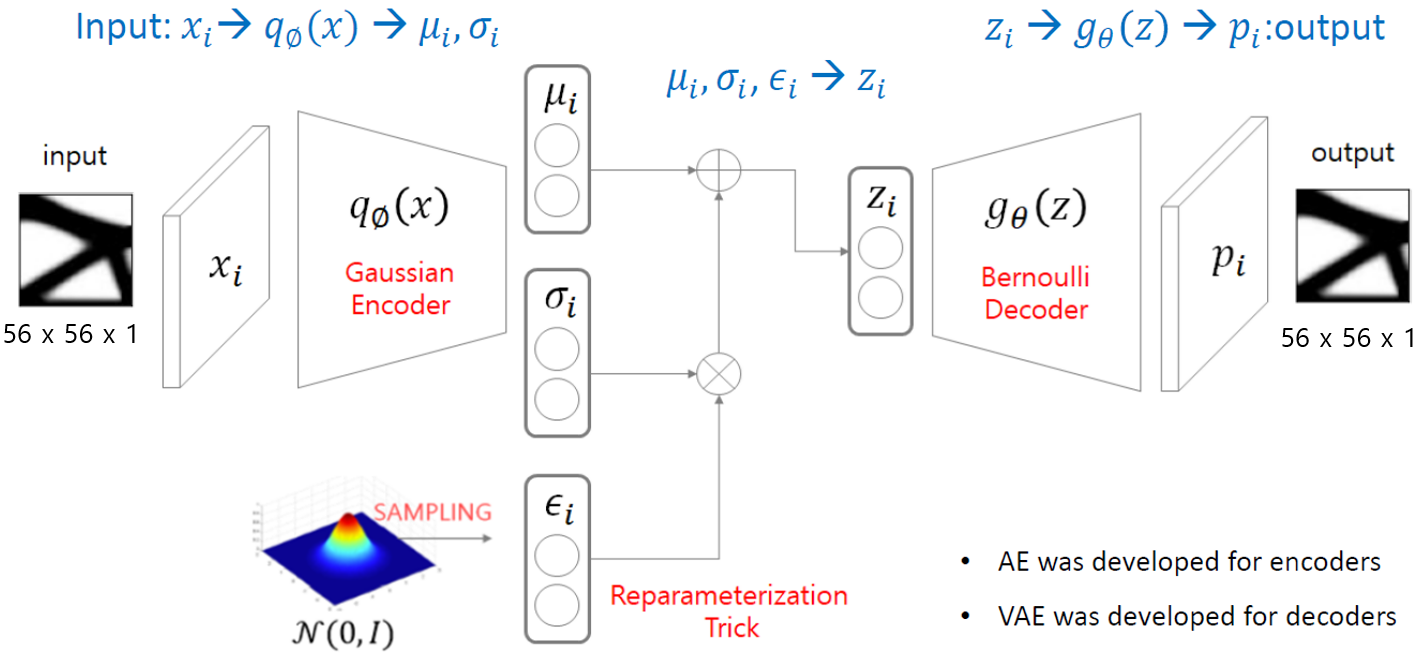

In [14]:
# ============================================================
# 6. VAE Model 정의
# ============================================================

class Encoder(nn.Module):
    def __init__(self, input_dim, intermediate_dim, latent_dim, dropout_rate=0.0):
        super(Encoder, self).__init__()

        self.fc1 = nn.Linear(input_dim, intermediate_dim)
        self.dropout = nn.Dropout(dropout_rate)

        self.fc2_mean = nn.Linear(intermediate_dim, latent_dim)
        self.fc2_logvar = nn.Linear(intermediate_dim, latent_dim)

    def forward(self, x):
        h = torch.relu(self.fc1(x))
        h = self.dropout(h)

        z_mean = self.fc2_mean(h)
        z_logvar = self.fc2_logvar(h)

        return z_mean, z_logvar

In [15]:
class Decoder(nn.Module):
    def __init__(self, latent_dim, intermediate_dim, output_dim, dropout_rate=0.0):
        super(Decoder, self).__init__()

        self.fc1 = nn.Linear(latent_dim, intermediate_dim)
        self.dropout = nn.Dropout(dropout_rate)
        self.fc2 = nn.Linear(intermediate_dim, output_dim)

    def forward(self, z):
        h = torch.relu(self.fc1(z))
        h = self.dropout(h)

        x_recon = torch.sigmoid(self.fc2(h))

        return x_recon

In [16]:
class VAE(nn.Module):
    def __init__(self, input_dim, intermediate_dim, latent_dim, dropout_rate=0.0):
        super(VAE, self).__init__()

        self.encoder = Encoder(
            input_dim=input_dim,
            intermediate_dim=intermediate_dim,
            latent_dim=latent_dim,
            dropout_rate=dropout_rate
        )

        self.decoder = Decoder(
            latent_dim=latent_dim,
            intermediate_dim=intermediate_dim,
            output_dim=input_dim,
            dropout_rate=dropout_rate
        )

    def reparameterize(self, z_mean, z_logvar):
        epsilon = torch.randn_like(z_mean)
        z = z_mean + torch.exp(0.5 * z_logvar) * epsilon
        return z

    def forward(self, x):
        z_mean, z_logvar = self.encoder(x)
        z = self.reparameterize(z_mean, z_logvar)
        x_recon = self.decoder(z)

        return x_recon, z_mean, z_logvar

In [17]:
# ============================================================
# 7. VAE Loss 정의
# ============================================================

def vae_loss(x, x_recon, z_mean, z_logvar, beta_kl=1.0):
    image_size = x.shape[1]

    # Reconstruction loss
    recon_loss = F.mse_loss(x_recon, x, reduction="sum")

    # KL divergence
    kl_loss = 0.5 * torch.sum(
        z_mean.pow(2) + z_logvar.exp() - z_logvar - 1
    )

    # beta-VAE 형태
    total_loss = (recon_loss + beta_kl * kl_loss) / image_size

    return total_loss, recon_loss / image_size, kl_loss / image_size


def l1_regularization(model):
    l1_penalty = 0.0

    for param in model.parameters():
        l1_penalty += torch.sum(torch.abs(param))

    return l1_penalty

In [18]:
# ============================================================
# 8. Model / Optimizer 초기화
# ============================================================

reset_seed(config["seed"])

vae = VAE(
    input_dim=input_dim,
    intermediate_dim=config["intermediate_dim"],
    latent_dim=config["latent_dim"],
    dropout_rate=config["dropout_rate"]
).to(device)

optimizer = optim.Adam(
    vae.parameters(),
    lr=config["lr"],
    weight_decay=config["weight_decay"]   # L2 regularization
)

print(vae)

# summary 확인
summary(vae, (input_dim,))

VAE(
  (encoder): Encoder(
    (fc1): Linear(in_features=3136, out_features=512, bias=True)
    (dropout): Dropout(p=0.0, inplace=False)
    (fc2_mean): Linear(in_features=512, out_features=2, bias=True)
    (fc2_logvar): Linear(in_features=512, out_features=2, bias=True)
  )
  (decoder): Decoder(
    (fc1): Linear(in_features=2, out_features=512, bias=True)
    (dropout): Dropout(p=0.0, inplace=False)
    (fc2): Linear(in_features=512, out_features=3136, bias=True)
  )
)
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                  [-1, 512]       1,606,144
           Dropout-2                  [-1, 512]               0
            Linear-3                    [-1, 2]           1,026
            Linear-4                    [-1, 2]           1,026
           Encoder-5         [[-1, 2], [-1, 2]]               0
            Linear-6                  [-1, 512]           1,536
          

In [19]:
# ============================================================
# 9. Training
# ============================================================

train_total_losses = []
train_recon_losses = []
train_kl_losses = []

val_total_losses = []
val_recon_losses = []
val_kl_losses = []

best_val_loss = float("inf")
best_model_state = None
best_epoch = 0

num_epochs = config["epochs"]

for epoch in range(num_epochs):
    # -------------------------
    # Train
    # -------------------------
    vae.train()

    train_total_sum = 0.0
    train_recon_sum = 0.0
    train_kl_sum = 0.0

    for x_batch, _ in train_loader:
        x_batch = x_batch.to(device)

        optimizer.zero_grad()

        x_recon, z_mean, z_logvar = vae(x_batch)

        total_loss, recon_loss, kl_loss = vae_loss(
            x_batch,
            x_recon,
            z_mean,
            z_logvar,
            beta_kl=config["beta_kl"]
        )

        # L1 regularization 추가
        if config["l1_lambda"] > 0:
            total_loss = total_loss + config["l1_lambda"] * l1_regularization(vae)

        total_loss.backward()
        optimizer.step()

        train_total_sum += total_loss.item()
        train_recon_sum += recon_loss.item()
        train_kl_sum += kl_loss.item()

    avg_train_total = train_total_sum / len(train_loader)
    avg_train_recon = train_recon_sum / len(train_loader)
    avg_train_kl = train_kl_sum / len(train_loader)

    train_total_losses.append(avg_train_total)
    train_recon_losses.append(avg_train_recon)
    train_kl_losses.append(avg_train_kl)

    # -------------------------
    # Validation
    # -------------------------
    vae.eval()

    val_total_sum = 0.0
    val_recon_sum = 0.0
    val_kl_sum = 0.0

    with torch.no_grad():
        for x_batch, _ in val_loader:
            x_batch = x_batch.to(device)

            x_recon, z_mean, z_logvar = vae(x_batch)

            total_loss, recon_loss, kl_loss = vae_loss(
                x_batch,
                x_recon,
                z_mean,
                z_logvar,
                beta_kl=config["beta_kl"]
            )

            val_total_sum += total_loss.item()
            val_recon_sum += recon_loss.item()
            val_kl_sum += kl_loss.item()

    avg_val_total = val_total_sum / len(val_loader)
    avg_val_recon = val_recon_sum / len(val_loader)
    avg_val_kl = val_kl_sum / len(val_loader)

    val_total_losses.append(avg_val_total)
    val_recon_losses.append(avg_val_recon)
    val_kl_losses.append(avg_val_kl)

    # best model 저장
    if avg_val_total < best_val_loss:
        best_val_loss = avg_val_total
        best_model_state = copy.deepcopy(vae.state_dict())
        best_epoch = epoch + 1

    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(
            f"Epoch [{epoch+1}/{num_epochs}] "
            f"Train Loss: {avg_train_total:.4f} "
            f"Val Loss: {avg_val_total:.4f} "
            f"Recon: {avg_val_recon:.4f} "
            f"KL: {avg_val_kl:.4f}"
        )

# best validation 모델로 복원
vae.load_state_dict(best_model_state)

print("=" * 60)
print("Training Finished")
print("Config:", config["name"])
print("Best Epoch:", best_epoch)
print("Best Val Loss:", best_val_loss)

Epoch [1/100] Train Loss: 1.7928 Val Loss: 1.4948 Recon: 1.4615 KL: 0.0332
Epoch [10/100] Train Loss: 1.3385 Val Loss: 1.3089 Recon: 1.2770 KL: 0.0320
Epoch [20/100] Train Loss: 1.2834 Val Loss: 1.2854 Recon: 1.2464 KL: 0.0391
Epoch [30/100] Train Loss: 1.2520 Val Loss: 1.2787 Recon: 1.2372 KL: 0.0414
Epoch [40/100] Train Loss: 1.2305 Val Loss: 1.2691 Recon: 1.2321 KL: 0.0370
Epoch [50/100] Train Loss: 1.2120 Val Loss: 1.2680 Recon: 1.2227 KL: 0.0453
Epoch [60/100] Train Loss: 1.1912 Val Loss: 1.2591 Recon: 1.2213 KL: 0.0378
Epoch [70/100] Train Loss: 1.1824 Val Loss: 1.2655 Recon: 1.2230 KL: 0.0425
Epoch [80/100] Train Loss: 1.1707 Val Loss: 1.2701 Recon: 1.2267 KL: 0.0434
Epoch [90/100] Train Loss: 1.1631 Val Loss: 1.2684 Recon: 1.2284 KL: 0.0401
Epoch [100/100] Train Loss: 1.1582 Val Loss: 1.2854 Recon: 1.2449 KL: 0.0405
Training Finished
Config: vae_baseline
Best Epoch: 52
Best Val Loss: 1.2543908804655075


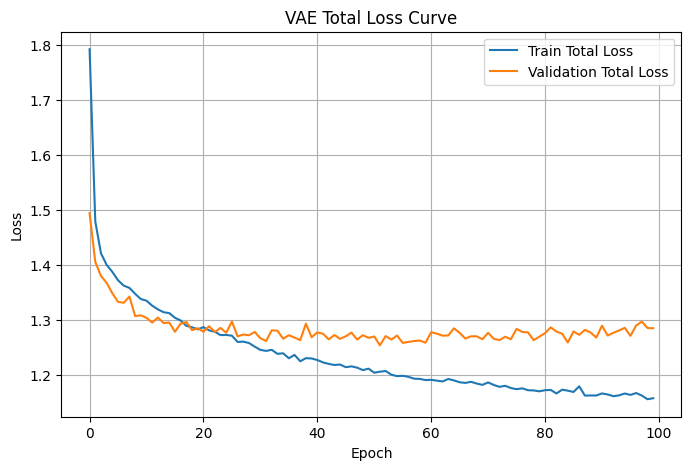

In [20]:
# ============================================================
# 10. Loss Curve
# ============================================================

plt.figure(figsize=(8, 5))
plt.plot(train_total_losses, label="Train Total Loss")
plt.plot(val_total_losses, label="Validation Total Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("VAE Total Loss Curve")
plt.legend()
plt.grid(True)
plt.show()

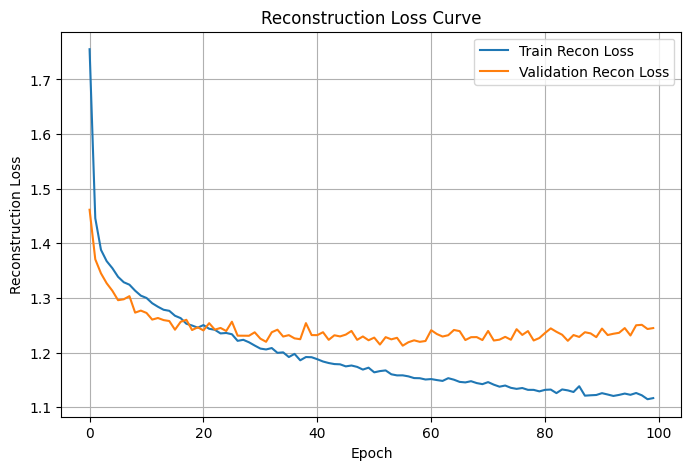

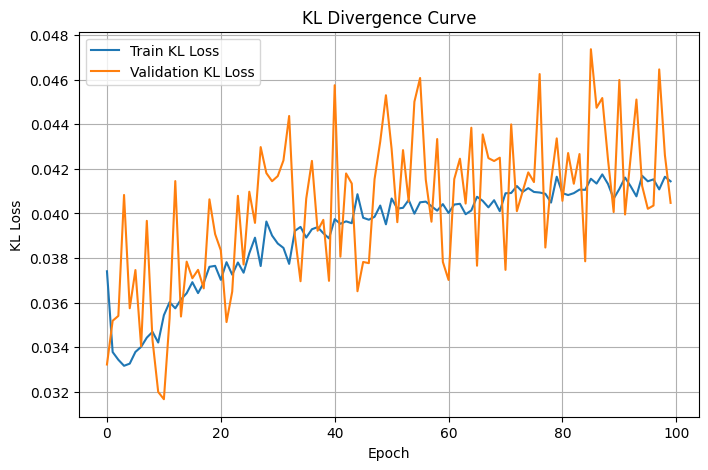

In [21]:
plt.figure(figsize=(8, 5))
plt.plot(train_recon_losses, label="Train Recon Loss")
plt.plot(val_recon_losses, label="Validation Recon Loss")
plt.xlabel("Epoch")
plt.ylabel("Reconstruction Loss")
plt.title("Reconstruction Loss Curve")
plt.legend()
plt.grid(True)
plt.show()


plt.figure(figsize=(8, 5))
plt.plot(train_kl_losses, label="Train KL Loss")
plt.plot(val_kl_losses, label="Validation KL Loss")
plt.xlabel("Epoch")
plt.ylabel("KL Loss")
plt.title("KL Divergence Curve")
plt.legend()
plt.grid(True)
plt.show()

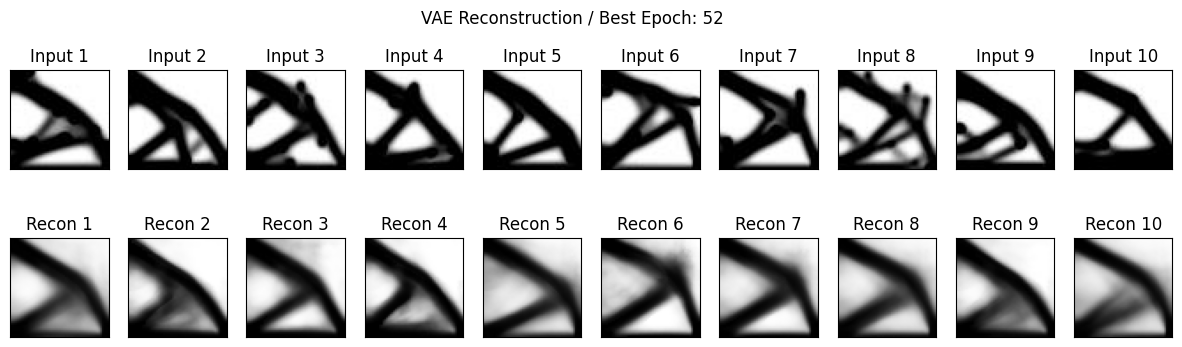

In [22]:
# ============================================================
# 11. Test Reconstruction 확인
# ============================================================

vae.eval()

test_images_eval = test_images_tensor.to(device)

with torch.no_grad():
    recon_x_test, z_mean_test, z_logvar_test = vae(test_images_eval)

n = 10

plt.figure(figsize=(15, 4))

for i in range(n):
    # 원본
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(
        test_images_eval.detach().cpu()[i].reshape(56, 56),
        vmin=0,
        vmax=1,
        cmap="gray"
    )
    plt.title(f"Input {i+1}")
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # 복원
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(
        recon_x_test.detach().cpu()[i].reshape(56, 56),
        vmin=0,
        vmax=1,
        cmap="gray"
    )
    plt.title(f"Recon {i+1}")
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

plt.suptitle(f"VAE Reconstruction / Best Epoch: {best_epoch}")
plt.show()

In [23]:
# ============================================================
# 12. Test Loss 계산
# ============================================================

vae.eval()

test_total_sum = 0.0
test_recon_sum = 0.0
test_kl_sum = 0.0

with torch.no_grad():
    for x_batch, _ in test_loader:
        x_batch = x_batch.to(device)

        x_recon, z_mean, z_logvar = vae(x_batch)

        total_loss, recon_loss, kl_loss = vae_loss(
            x_batch,
            x_recon,
            z_mean,
            z_logvar,
            beta_kl=config["beta_kl"]
        )

        test_total_sum += total_loss.item()
        test_recon_sum += recon_loss.item()
        test_kl_sum += kl_loss.item()

test_total_loss = test_total_sum / len(test_loader)
test_recon_loss = test_recon_sum / len(test_loader)
test_kl_loss = test_kl_sum / len(test_loader)

print("=" * 60)
print("Test Result")
print(f"Test Total Loss : {test_total_loss:.4f}")
print(f"Test Recon Loss : {test_recon_loss:.4f}")
print(f"Test KL Loss    : {test_kl_loss:.4f}")

Test Result
Test Total Loss : 1.3485
Test Recon Loss : 1.3125
Test KL Loss    : 0.0359


z_mean shape: (600, 2)


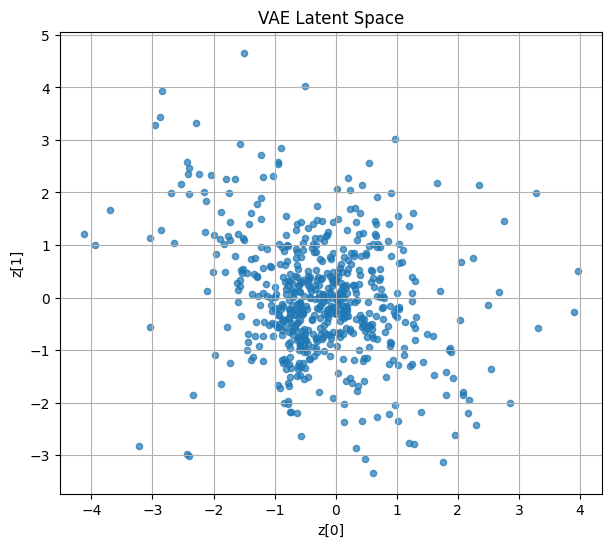

In [24]:
# ============================================================
# 13. Latent Space 시각화
# ============================================================

vae.eval()

with torch.no_grad():
    _, z_mean_test, _ = vae(test_images_tensor.to(device))

z_mean_np = z_mean_test.detach().cpu().numpy()

print("z_mean shape:", z_mean_np.shape)

if config["latent_dim"] == 2:
    plt.figure(figsize=(7, 6))
    plt.scatter(
        z_mean_np[:, 0],
        z_mean_np[:, 1],
        s=20,
        alpha=0.7
    )
    plt.xlabel("z[0]")
    plt.ylabel("z[1]")
    plt.title("VAE Latent Space")
    plt.grid(True)
    plt.show()
else:
    print("latent_dim이 2가 아니므로 바로 2D scatter는 불가합니다.")

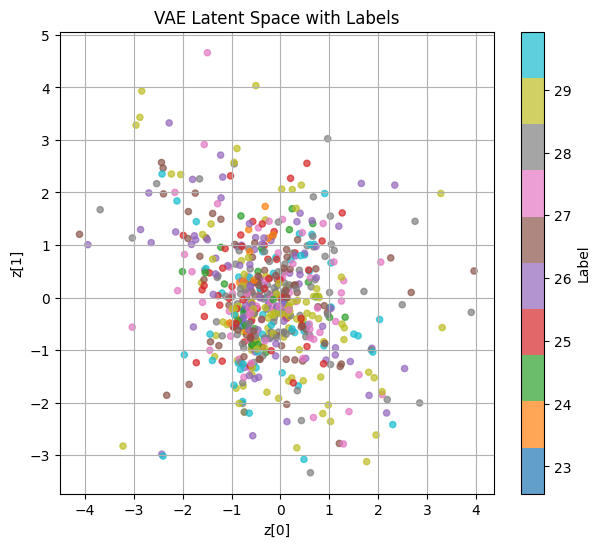

In [26]:
if "test_labels" in globals() and config["latent_dim"] == 2:
    labels_np = test_labels.detach().cpu().numpy() if isinstance(test_labels, torch.Tensor) else np.array(test_labels)

    plt.figure(figsize=(7, 6))
    scatter = plt.scatter(
        z_mean_np[:, 0],
        z_mean_np[:, 1],
        c=labels_np,
        cmap="tab10",
        s=20,
        alpha=0.7
    )
    plt.colorbar(scatter, label="Label")
    plt.xlabel("z[0]")
    plt.ylabel("z[1]")
    plt.title("VAE Latent Space with Labels")
    plt.grid(True)
    plt.show()

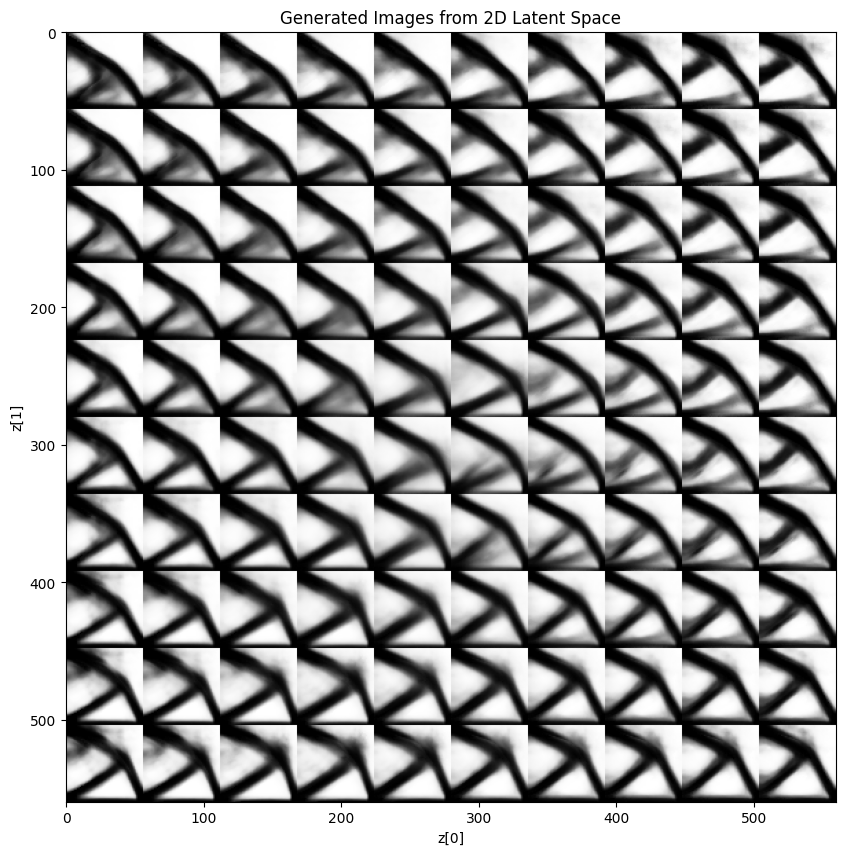

In [25]:
# ============================================================
# 14. Latent Space Grid 생성
# ============================================================

def plot_latent_space(vae, n=10, digit_size=56, device=device):
    vae.eval()

    figure = np.zeros((digit_size * n, digit_size * n))

    grid_x = np.linspace(-2, 2, n)
    grid_y = np.linspace(-2, 2, n)[::-1]

    with torch.no_grad():
        for i, yi in enumerate(grid_y):
            for j, xi in enumerate(grid_x):
                z_sample = torch.tensor(
                    [[xi, yi]],
                    dtype=torch.float32
                ).to(device)

                x_decoded = vae.decoder(z_sample).detach().cpu().numpy()
                digit = x_decoded[0].reshape(digit_size, digit_size)

                figure[
                    i * digit_size: (i + 1) * digit_size,
                    j * digit_size: (j + 1) * digit_size
                ] = digit

    plt.figure(figsize=(10, 10))
    plt.imshow(figure, cmap="Greys_r")
    plt.xlabel("z[0]")
    plt.ylabel("z[1]")
    plt.title("Generated Images from 2D Latent Space")
    plt.show()


if config["latent_dim"] == 2:
    plot_latent_space(vae, n=10, digit_size=56, device=device)
else:
    print("latent_dim이 2일 때만 grid latent space 생성이 가능합니다.")